<a href="https://colab.research.google.com/github/OptimizationExpert/Pyomo/blob/main/Farmer_CP_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ortools
from ortools.sat.python import cp_model # CP-SAT solver
import numpy as np
from random import randint
import random
from math import ceil, floor
import pandas as pd
import matplotlib.pyplot as plt # Data visualization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 24.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.

# Data

https://improbable.com/news/2012/Optimal-seating-chart.pdf

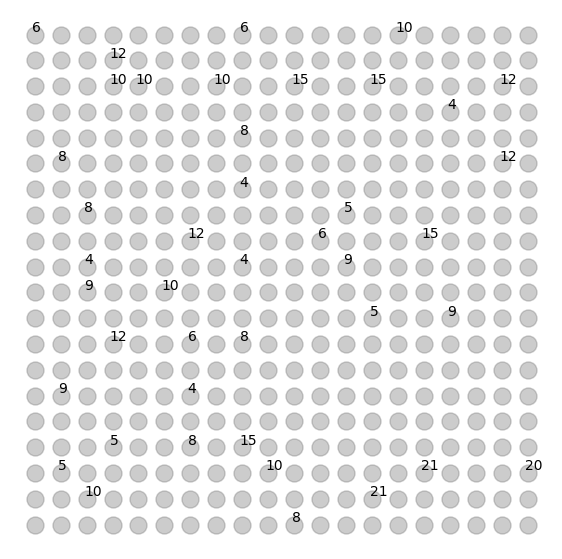

In [2]:
from typing_extensions import no_type_check_decorator
import pandas as pd

data = [
    [12,18,5],
    [5,13,11],
    [15,10,2],
    [12,3,12],
    [8,2,7],
    [8,8,12],
    [6,8,0],
    [8,8,4],
    [4,6,14],
    [6,11,8],
    [10,14,0],
    [21,15,17],
    [15,15,8],
    [9,16,11],
    [21,13,18],
    [5,3,16],
    [12,3,1],
    [8,10,19],
    [4,8,9],
    [9,2,10],
    [4,16,3],
    [10,2,18],
    [6,6,12],
    [10,3,2],
    [10,9,17],
    [4,2,9],
    [5,1,17],
    [5,12,7],
    [12,18,2],
    [8,6,16],
    [12,6,8],
    [4,8,6],
    [10,4,2],
    [8,1,5],
    [9,1,14],
    [9,12,9],
    [15,13,2],
    [10,7,2],
    [15,8,16],
    [10,5,10],
    [6,0,0],
    [20,19,17]
]


#data = [[3, 3, 1], [3, 2, 0],[4, 2, 1],[3, 0, 1],[3, 0, 3]]


data_dict = {}
for r in data:
  if r[0] not in data_dict:
    data_dict[r[0]] = [r[1:3]]
  else:
    data_dict[r[0]].append( r[1:3])


plt.figure(figsize=(7,7))
nodes = []
data = {}
data_v = {}
counter = 0

nr, nc =4 ,4
nr, nc =20 , 20

for r in range(nr):
  for c in range(nc):
    #plt.text(r , 20 -c , s=str('.'))
    plt.scatter(r-0.1 , nc -c-0.1 , s=150 , c= 'grey' , alpha=0.4)
    #plt.text(r , nc -c , s=f"{counter}", c='r', fontsize=5)
    #plt.text(r , nc -c , s=f" {r}_{nc-c} ", c='k', fontsize=5)
    nodes.append(counter)
    data[counter] = [r , nc -c, 0]
    data_v[r , nc -c] = counter
    counter+=1


for v, LL in data_dict.items():
  for (x0,y0) in LL:
      plt.text(x0-0.2 , nc -y0 , s=str(v))
      n= data_v[x0 , nc -y0]
      data[n][2] = v
plt.axis('off')
plt.show()

def surface(i,j):
  return int((abs(data[i][0]-data[j][0]) + 1)*(1+abs(data[i][1]-data[j][1])))

In [3]:
sources = {}
for n , [x0,y0,v] in data.items():
  if v>0:
    print(n , [x0,y0,v])
    sources[n] = v

print(sum(sources.values()))
exsource = {x: [y for y in sources if y != x] for x in sources}
KOLORS= {1:'r', 3:'b',8:'g',9:'k', 13:'gold'}

0 [0, 20, 6]
25 [1, 15, 8]
34 [1, 6, 9]
37 [1, 3, 5]
47 [2, 13, 8]
49 [2, 11, 4]
50 [2, 10, 9]
58 [2, 2, 10]
61 [3, 19, 12]
62 [3, 18, 10]
72 [3, 8, 12]
76 [3, 4, 5]
82 [4, 18, 10]
110 [5, 10, 10]
128 [6, 12, 12]
132 [6, 8, 6]
134 [6, 6, 4]
136 [6, 4, 8]
142 [7, 18, 10]
160 [8, 20, 6]
164 [8, 16, 8]
166 [8, 14, 4]
169 [8, 11, 4]
172 [8, 8, 8]
176 [8, 4, 15]
197 [9, 3, 10]
202 [10, 18, 15]
219 [10, 1, 8]
228 [11, 12, 6]
247 [12, 13, 5]
249 [12, 11, 9]
262 [13, 18, 15]
271 [13, 9, 5]
278 [13, 2, 21]
280 [14, 20, 10]
308 [15, 12, 15]
317 [15, 3, 21]
323 [16, 17, 4]
331 [16, 9, 9]
362 [18, 18, 12]
365 [18, 15, 12]
397 [19, 3, 20]
400


In [4]:
def Left(i,s):
  Ax= data[i][0]<= data[s][0]
  Ay= data[i][1]<= data[s][1]
  return Ax and Ay

def Right(j,s):
  Bx= data[j][0]>= data[s][0]
  By= data[j][1]>= data[s][1]
  return Bx and By

def dist(i,j):
  return abs(data[i][0]-data[j][0]) + abs(data[i][1]-data[j][1])
def check(i,j,s):
  Z = (j!=i)
  if not Z:
    return False

  Y = (i!=s or j!=s)
  if not Y:
    return False
  area = sources[s] == surface(i,j)
  if not area:
    return False

  if dist(i,s)>data[s][2] or dist(j,s)>data[s][2]:
    return False

  for ss in sources:
    if ss!=s:
      ax= data[i][0]<= data[ss][0]
      ay= data[i][1]<= data[ss][1]
      ax=  data[ss][0] <= data[j][0]
      ay=  data[ss][1] <= data[j][1]
      if Left(i,ss) and Right(j,ss):
        return False
  return Left(i,s) and Right(j,s) and Z and area and Y



ex_source = {}
for s in sources:
  s_list= [ss for ss in sources ]
  s_list.remove(s)
  ex_source[s] = [n for n in nodes if n not in s_list ]

print(ex_source)



{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 51, 52, 53, 54, 55, 56, 57, 59, 60, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 77, 78, 79, 80, 81, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131, 133, 135, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 161, 162, 163, 165, 167, 168, 170, 171, 173, 174, 175, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 198, 199, 200, 201, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 220, 221, 222, 223, 224, 225, 226, 227, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246

In [6]:
len(sources)

42

In [15]:
model = cp_model.CpModel()
solver = cp_model.CpSolver()

selected = {(i,j,s):model.NewBoolVar(f"select_{i}_{j}_{s}")
 for i in nodes for j in nodes for s in sources if check(i,j,s) }

assign = {(i,s):model.NewBoolVar(f"A_{i}_{s}")
 for i in nodes for s in sources if i in ex_source[s] and dist(i,s)<= data[s][2]}
print('hero', len(assign))

for i in nodes:
  if i in sources:
    model.Add(assign[i,i] == 1)

  expr = [assign.get((i,s),0) for s in sources]
  model.AddExactlyOne(expr)

for (i,j,s),v in selected.items():
  expr = [assign[n,s] for n in nodes if Right(j,n) and Left(i,n) ]
  model.Add(len(expr)*v <= sum(expr))

print(selected.keys())
for s in sources:
  expr= [ v for (i,j,ss),v in selected.items() if s==ss]
  model.AddExactlyOne(expr)

for (i,j,s),v in selected.items():
  model.Add(v <= assign[i,s])
  model.Add(v <= assign[j,s])

solver.parameters.max_time_in_seconds = 20
status = solver.Solve(model)
print(solver.status_name(status) )
if status == cp_model.OPTIMAL:
  print(solver.ObjectiveValue())


hero 5155
dict_keys([(0, 100, 0), (1, 40, 0), (1, 221, 61), (2, 20, 0), (5, 0, 0), (5, 22, 25), (5, 64, 25), (5, 145, 25), (6, 23, 25), (6, 65, 25), (7, 24, 25), (7, 66, 47), (7, 147, 47), (8, 25, 25), (8, 67, 47), (9, 69, 49), (12, 50, 50), (12, 111, 72), (13, 71, 72), (13, 112, 72), (14, 52, 34), (15, 53, 34), (16, 54, 34), (16, 96, 76), (17, 97, 37), (18, 198, 58), (19, 98, 58), (21, 120, 61), (21, 241, 61), (24, 164, 164), (25, 42, 25), (25, 84, 25), (25, 165, 25), (26, 43, 25), (26, 85, 25), (27, 20, 25), (27, 86, 47), (27, 167, 47), (28, 21, 25), (28, 87, 47), (29, 22, 25), (29, 48, 49), (29, 89, 49), (30, 23, 25), (31, 24, 25), (32, 25, 25), (33, 91, 72), (34, 26, 34), (35, 27, 34), (35, 73, 34), (36, 28, 34), (36, 116, 76), (37, 117, 37), (38, 218, 58), (39, 35, 37), (39, 118, 58), (41, 140, 61), (41, 261, 61), (44, 184, 164), (46, 62, 62), (47, 40, 47), (47, 64, 47), (47, 106, 47), (47, 187, 47), (48, 41, 47), (48, 65, 47), (48, 107, 47), (49, 68, 49), (49, 109, 49), (53, 111,

(np.float64(-0.9500000000000001),
 np.float64(19.95),
 np.float64(0.04999999999999993),
 np.float64(20.95))

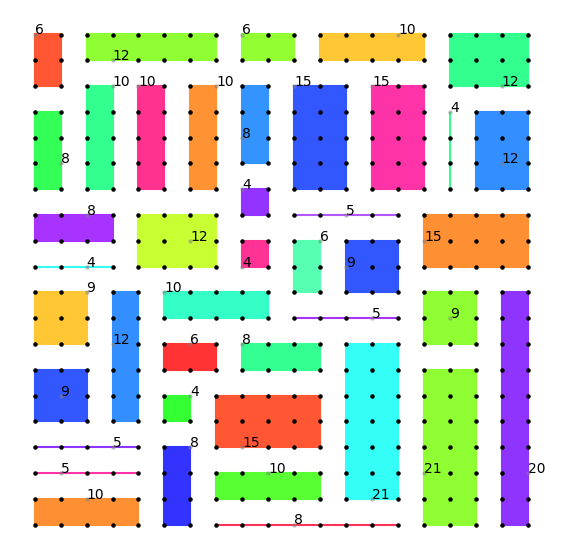

In [17]:
colors = [
    "#FF5733",
    "#33FF57",
    "#3357FF",
    "#FF33A8",
    "#A833FF",
    "#33FFF6",
    "#FFC733",
    "#FF8F33",
    "#8FFF33",
    "#33FF8F",
    "#338FFF",
    "#8F33FF",
    "#FF338F",
    "#33FFC7",
    "#C7FF33",
    "#FF3333",
    "#33FF33",
    "#3333FF",
    "#FF9333",
    "#93FF33",
    "#3393FF",
    "#9333FF",
    "#FF3393",
    "#33FF93",
    "#FF5733",
    "#57FF33",
    "#3357FF",
    "#FF3357",
    "#57FFB2",
    "#B257FF",
        "#3357FF",
    "#FF33A8",
    "#A833FF",
    "#33FFF6",
    "#FFC733",
    "#FF8F33",
    "#8FFF33",
    "#33FF8F",
        "#8FFF33",
    "#33FF8F",
    "#338FFF",
    "#8F33FF",
    "#FF338F",
    "#33FFC7",
    "#C7FF33",
    "#FF3333",
    "#33FF33",
    "#3333FF",
    "#FF9333",
    "#93FF33",
    "#3393FF",
    "#9333FF",
    "#FF3393",
]


import matplotlib.pyplot as plt
import matplotlib.patches as patches



# Create a rectangle

fig, ax = plt.subplots(figsize=(7,7))
for n , [x0,y0,v] in data.items():
  if v>0:
    plt.text(x0,y0 , s=str(v), zorder=2)
    #plt.text(x0,y0-0.2 , s=str(n), c='r')
    plt.scatter(x0,y0 , s=5 , c='grey' , alpha=0.4, zorder=2)
  else:
    plt.scatter(x0,y0 , s=5 , c='k' , alpha=1, zorder=2)
    #plt.text(x0,y0-0.3 , s=str(n), c='r', fontsize=5)

s_list = [s for s in sources]

for (i,j,s),v in selected.items():
  if solver.BooleanValue(v):
    #print('xxx', i,j , s)
    sindx = s_list.index(s)
    #plt.scatter(data[i][0],data[i][1] , s=150 , c=colors[sindx] , alpha=1)
    x0,y0 = data[i][0],data[i][1]
    x1,y1 = data[j][0],data[j][1]
    rect = patches.Rectangle(
    (x0,y0),   # (x, y) bottom-left corner
    x1-x0,          # width
    y1-y0,          # height
    linewidth=1.5,
    edgecolor=colors[sindx],
    facecolor=colors[sindx]
)
    ax.add_patch(rect)



plt.axis('off')


(np.float64(-0.9500000000000001),
 np.float64(19.95),
 np.float64(0.04999999999999993),
 np.float64(20.95))

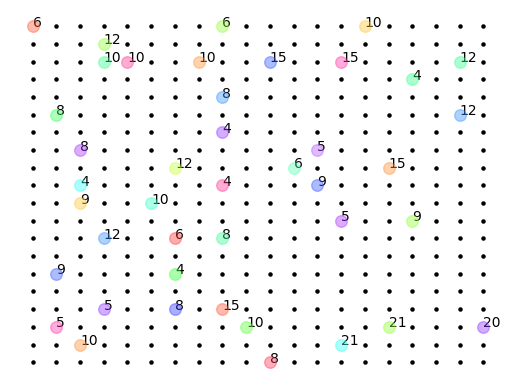

In [12]:
fig, ax = plt.subplots()
for n , [x0,y0,v] in data.items():
  if v>0:
    sindx = s_list.index(n)

    plt.text(x0,y0 , s=str(v), zorder=2)
    #plt.text(x0,y0-0.2 , s=str(n), c='r')
    plt.scatter(x0,y0 , s=70 , c=colors[sindx] , alpha=0.4, zorder=2)
  else:
    plt.scatter(x0,y0 , s=5 , c='k' , alpha=1, zorder=2)
    #plt.text(x0,y0-0.3 , s=str(n), c='r', fontsize=5)




plt.axis('off')
